In [185]:
from database.adatabase import ADatabase
import pandas as pd
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
from datetime import datetime, timedelta, timezone
from xgboost import XGBRegressor
import random

In [186]:
db = ADatabase("algo")
market = ADatabase("market")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [187]:
russell1000

,Company,ticker,GICS Sector,GICS Sub-Industry
0,10x Genomics,TXG,Health Care,NaN
1,3M,MMM,Industrials,Industrial Conglomerates
2,Abbott,ABT,Health Care,Health Care Equipment
3,AbbVie,ABBV,Health Care,Pharmaceuticals
4,Acadia Healthcare,ACHC,Health Care,Health Care Facilities
...,...,...,...,...
1004,Zions Bancorporation,ZION,Financials,Regional Banks
1005,Zoetis,ZTS,Health Care,Pharmaceuticals
1006,Zoom,ZM,Information Technology,Application Software
1007,ZoomInfo,ZI,Communication Services,NaN


In [188]:
tickers = russell1000["ticker"].values
training_year = datetime.now().year - 3
holding_period = 5
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
factors = ["historical_return","skew","kurtosis","average_return","coefficient_of_variance"]

In [189]:
market.connect()
prices = []
model = XGBRegressor()
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","week","month","weekday","ticker","adjclose"]]
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["historical_return"] = (ticker_prices["adjclose"] - ticker_prices["adjclose"].shift(5)) / ticker_prices["adjclose"].shift(5)
        ticker_prices["skew"] = ticker_prices["historical_return"].rolling(100).skew()
        ticker_prices["kurtosis"] = ticker_prices["historical_return"].rolling(100).kurt()
        ticker_prices["skurtosis"] = ticker_prices["skew"] * ticker_prices["kurtosis"]
        ticker_prices["average_return"] = ticker_prices["historical_return"].rolling(100).mean()
        ticker_prices["coefficient_of_variance"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["price_to_rolling"] = ticker_prices["adjclose"] / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["price_to_bollinger"] = ticker_prices["adjclose"] / (ticker_prices["adjclose"].rolling(100).mean() + 2 * ticker_prices["adjclose"].rolling(100).std()) 
        ticker_prices["random"] = [random.randint(0,1009) for x in ticker_prices.iterrows()]
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["sell_date"] = ticker_prices["date"] + timedelta(days=holding_period/5*7)
        ticker_prices["y"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"]
        training_data = ticker_prices.iloc[100:200].dropna()
        simulation = ticker_prices.iloc[200:]
        model.fit(training_data[factors],training_data["y"])
        if simulation.index.size > 0:
            prices.append(simulation)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()

model_prep: 100%|██████████| 1009/1009 [03:37<00:00,  4.64it/s]


In [257]:
simulation.drop(["date","ticker"],axis=1).corr()

,week,month,weekday,adjclose,historical_return,skew,kurtosis,skurtosis,average_return,coefficient_of_variance,price_to_rolling,price_to_bollinger,random,buy_price,buy_date,sell_price,sell_date,y
week,1.000000,0.996711,-0.013475,0.608391,-0.030945,0.031444,-0.118446,-0.058091,0.533848,-0.395502,0.263685,0.389831,0.061565,0.598385,0.320061,0.550613,0.325427,-0.054031
month,0.996711,1.000000,0.000298,0.603031,-0.031578,0.030011,-0.119539,-0.060238,0.530738,-0.399908,0.259492,0.386994,0.066278,0.592767,0.317842,0.551088,0.322735,-0.039999
weekday,-0.013475,0.000298,1.000000,-0.001266,0.024233,0.006081,0.007948,0.014743,0.000919,0.046258,-0.004710,-0.019416,0.016559,-0.004388,0.004815,-0.020728,0.007986,-0.017737
adjclose,0.608391,0.603031,-0.001266,1.000000,0.272114,-0.085919,-0.089656,-0.009597,0.748801,-0.144398,0.807682,0.850860,0.002057,0.988466,0.705984,0.939956,0.709456,-0.058451
historical_return,-0.030945,-0.031578,0.024233,0.272114,1.000000,0.144933,0.143867,0.172809,0.161027,0.028631,0.367774,0.363848,0.002927,0.277897,0.179909,0.286074,0.178256,0.000980
skew,0.031444,0.030011,0.006081,-0.085919,0.144933,1.000000,0.941484,0.925038,0.409803,0.456052,0.222922,0.060777,0.087189,-0.074017,0.088187,0.012404,0.083070,0.139749
kurtosis,-0.118446,-0.119539,0.007948,-0.089656,0.143867,0.941484,1.000000,0.978063,0.406862,0.544079,0.290975,0.096070,0.071156,-0.075590,0.144197,-0.008719,0.134781,0.097981
skurtosis,-0.058091,-0.060238,0.014743,-0.009597,0.172809,0.925038,0.978063,1.000000,0.472283,0.502665,0.365723,0.183215,0.090503,0.002163,0.249048,0.069314,0.242531,0.127015
average_return,0.533848,0.530738,0.000919,0.748801,0.161027,0.409803,0.406862,0.472283,1.000000,-0.017551,0.806571,0.796769,0.036485,0.743788,0.712960,0.725534,0.715088,0.018722
coefficient_of_variance,-0.395502,-0.399908,0.046258,-0.144398,0.028631,0.456052,0.544079,0.502665,-0.017551,1.000000,0.124889,-0.215863,0.031886,-0.151792,-0.083906,-0.180930,-0.079113,0.011224


In [265]:
sim = pd.concat(prices).reset_index(drop=True)
positions = len(russell1000["GICS Sector"].unique())
hedge_percentage = 1
sim["expected_return"] = model.predict(sim[factors])
sim["return"] = sim["y"]
sim = sim.merge(russell1000,on="ticker")
sim["month"] = [x.month for x in sim["date"]]
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = processor.column_date_processing(trades)
market.connect()
benchmark = processor.column_date_processing(market.query("prices",{"ticker":"AMZN"}))[["date","adjclose"]]
market.disconnect()

In [275]:
analysis = []
for valuation_method in factors + ["expected_return","random","price_to_rolling","price_to_bollinger","skurtosis"]:
    for ascending in [True,False]:
        for sector_based in [True,False]:
            all_sector_trades = []
            if sector_based == True:
                for sector in russell1000["GICS Sector"].unique():
                    sector_trades = trades[trades["gics sector"]==sector].copy()
                    sector_trades = sector_trades.sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(-4,6,2)]).reset_index()
                    sector_trades["sub_position"] = [i % 7 for i in sector_trades.index.values]
                    sector_trades["sub_weight"] = [1/2**float((i+1)) for i in sector_trades["sub_position"]]
                    all_sector_trades.append(sector_trades)
                iteration_trades = pd.concat(all_sector_trades)
            else:
                iteration_trades = trades.copy().sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
                iteration_trades["sub_weight"] = 1
            iteration_trades["weight"] = iteration_trades["sub_weight"] * (1/positions)
            iteration_trades["return"] = iteration_trades["return"] * iteration_trades["weight"] * 0.995
            iteration_trades["return"] = [max(float(-hedge_percentage*row[1]["weight"]),row[1]["return"]) for row in iteration_trades.iterrows()]
            portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
            portfolio.sort_values("date",inplace=True)
            portfolio = portfolio[(portfolio["date"]>portfolio["date"].min()) & (portfolio["date"]<portfolio["date"].max())]
            portfolio = portfolio.merge(benchmark,on="date")
            portfolio["benchmark_cumulative_return"] = (portfolio["adjclose"] - portfolio["adjclose"].iloc[0]) / portfolio["adjclose"].iloc[0] + 1
            portfolio["return"] = portfolio["return"] + 1
            portfolio["rolling_return"] = portfolio["return"].rolling(10).mean() 
            portfolio["skew"] = portfolio["return"].rolling(10).skew()
            portfolio["kurtosis"] = portfolio["return"].rolling(10).kurt()
            portfolio["cumulative_return"] = portfolio["return"].cumprod()
            portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
            portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
            analysis.append({
                "vm":valuation_method,
                "asc":ascending,
                "sector_based":sector_based,
                "lower_bound":portfolio["lower"].tail(1).item(),
                "skew": iteration_trades["return"].skew(),
                "kurtosis": iteration_trades["return"].kurt(),
                "cr":portfolio["cumulative_return"].tail(1).item(),
                "std":portfolio["cumulative_return"].std(),
                "coefficient_of_variance":portfolio["cumulative_return"].std()/portfolio["cumulative_return"].tail(1).item(),
                "return_to_std":portfolio["cumulative_return"].tail(1).item() / portfolio["cumulative_return"].std(),
                "treynor":portfolio["cumulative_return"].tail(1).item() / portfolio["cumulative_return"].cov(portfolio["benchmark_cumulative_return"]),
                "winrate":iteration_trades[iteration_trades["return"]>0].index.size/iteration_trades.index.size,
                "average_win":iteration_trades[iteration_trades["return"]>0]["return"].median() * 10
            })

In [276]:
a = pd.DataFrame(analysis).sort_values("lower_bound",ascending=False).reset_index(drop=True)
a

,vm,asc,sector_based,lower_bound,skew,kurtosis,cr,std,coefficient_of_variance,return_to_std,treynor,winrate,average_win
0,coefficient_of_variance,False,True,0.706191,-8.417860,94.431276,0.519186,0.121667,0.234342,4.267265,83.483974,0.508211,0.001573
1,average_return,True,True,0.695024,-9.097219,104.760732,0.493026,0.123814,0.251130,3.982004,63.761822,0.504985,0.001727
2,skew,False,True,0.614582,-10.173746,118.980554,0.452593,0.088255,0.194999,5.128220,-195.304305,0.510557,0.001328
3,kurtosis,True,True,0.606999,-8.849787,121.851623,0.434771,0.092672,0.213152,4.691478,-199.088585,0.508211,0.001165
4,skurtosis,True,True,0.590453,-9.680837,111.893485,0.416610,0.091130,0.218742,4.571599,-340.983194,0.511730,0.001210
5,average_return,False,True,0.577127,-8.584562,94.089998,0.421391,0.096067,0.227977,4.386415,9755.966326,0.499413,0.001497
6,historical_return,False,True,0.513840,-9.519755,109.312177,0.357400,0.098178,0.274700,3.640341,-42.656594,0.500000,0.001445
7,expected_return,False,True,0.509190,-9.417937,99.466645,0.333079,0.093680,0.281255,3.555490,-65.836994,0.509677,0.001148
8,historical_return,True,True,0.508309,-8.916821,98.401446,0.324508,0.104770,0.322856,3.097353,-63.771108,0.504985,0.001510
9,random,True,True,0.506637,-9.257004,94.887470,0.336096,0.094857,0.282233,3.543167,-59.918934,0.505572,0.001190


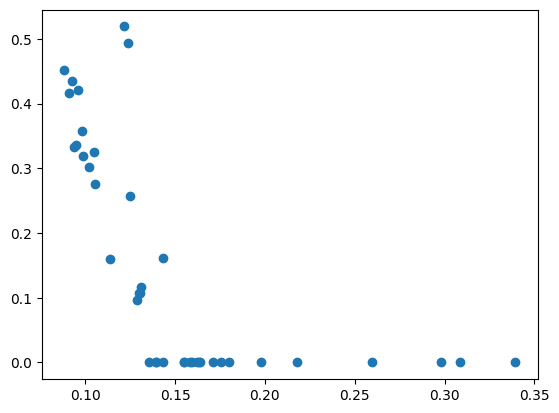

In [268]:
plt.scatter(a["std"],a["cr"])
plt.show()

In [269]:
valuation_method = "price_to_bollinger"
ascending = True
sector_based = False

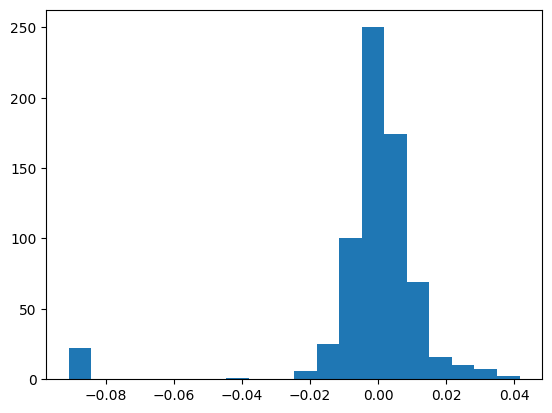

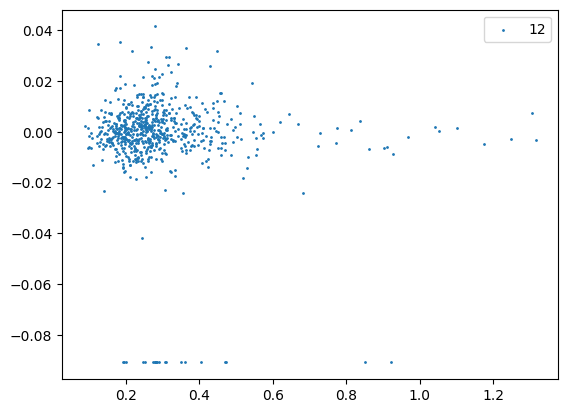

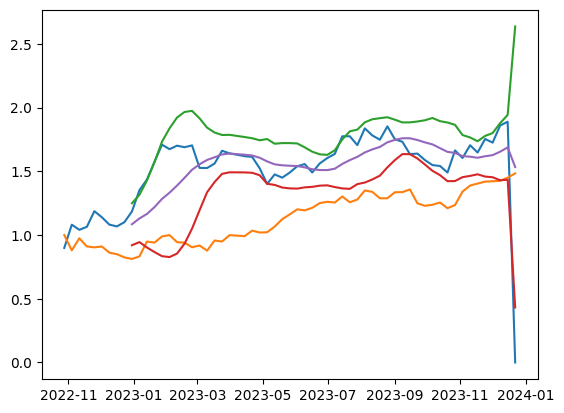

In [270]:
try:
    all_sector_trades = []
    if sector_based == True:
        for sector in russell1000["GICS Sector"].unique():
            sector_trades = trades[trades["gics sector"]==sector].copy()
            sector_trades = sector_trades.sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(-4,6,2)]).reset_index()
            sector_trades["sub_position"] = [i % 7 for i in sector_trades.index.values]
            sector_trades["sub_weight"] = [1/2**float((i+1)) for i in sector_trades["sub_position"]]
            sector_trades["weight"] = sector_trades["sub_weight"] * (1/positions)
            sector_trades["return"] = sector_trades["return"] * sector_trades["weight"] * 0.995
            sector_trades["return"] = [max(float(-hedge_percentage*row[1]["weight"]),row[1]["return"]) for row in sector_trades.iterrows()]
            all_sector_trades.append(sector_trades)
        iteration_trades = pd.concat(all_sector_trades)
    else:
        iteration_trades = trades.copy().sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
        iteration_trades["weight"] = [(1/positions) for i in range(iteration_trades.index.size)]
        iteration_trades["return"] = iteration_trades["return"] * iteration_trades["weight"] * 0.995
        iteration_trades["return"] = [max(float(-hedge_percentage*row[1]["weight"]),row[1]["return"]) for row in iteration_trades.iterrows()]
    portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio = portfolio[(portfolio["date"]>portfolio["date"].min()) & (portfolio["date"]<portfolio["date"].max())]
    portfolio = portfolio.merge(benchmark,on="date")
    portfolio["benchmark_cumulative_return"] = (portfolio["adjclose"] - portfolio["adjclose"].iloc[0]) / portfolio["adjclose"].iloc[0] + 1
    portfolio["return"] = portfolio["return"] + 1
    portfolio["rolling_return"] = portfolio["return"].rolling(10).mean() 
    portfolio["skew"] = portfolio["return"].rolling(10).skew()
    portfolio["kurtosis"] = portfolio["return"].rolling(10).kurt()
    portfolio["cumulative_return"] = portfolio["return"].cumprod()
    portfolio["mid"] = portfolio["cumulative_return"].rolling(10).mean()
    portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
    portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method,"weight","gics sector"]].sort_values(["date"]).tail(positions*7)
    plt.hist(iteration_trades["return"],bins=20,histtype="barstacked")
    plt.show()
    scatter = iteration_trades.sort_values("return")
    plt.scatter(scatter["coefficient_of_variance"].values,scatter["return"].values,s=1)
    plt.legend(list(iteration_trades["month"].unique()))
    plt.show()
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["benchmark_cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["upper"].values)
    plt.plot(portfolio["date"].values,portfolio["lower"].values)
    plt.plot(portfolio["date"].values,portfolio["mid"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [271]:
iteration_trades[["date","gics sector",valuation_method,"weight","sub_weight","sub_position","return"]].sort_values("return",ascending=True).head(10)

KeyError: "['sub_weight', 'sub_position'] not in index"

In [ ]:
recommendations.sort_values("date").tail(positions)

In [ ]:
db.connect()
# db.drop('portfolio')
# db.drop('trades')
db.drop('recommendations')
# db.store("portfolio",portfolio)
# db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()